In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.signal import savgol_filter
from scipy.spatial import distance
from tqdm import trange, tqdm
import networkx as nx
from shapely.geometry import Polygon, MultiPolygon, Point, MultiLineString, LineString, JOIN_STYLE
from shapely.geometry.polygon import LinearRing
from shapely.ops import unary_union
import h5py

In [ ]:
import sys
sys.path.append('../')

In [7]:
import meandergraph as mg

In [8]:
from importlib import reload
reload(mg);

In [9]:
%matplotlib qt

In [10]:
fname = '/Users/zoltan/Dropbox/Meandergraph/meandergraph_example_model_1_all_data.hdf5'
f = h5py.File(fname, 'r')
P = []
Q = []
P1 = []
Q1 = []
P2 = []
Q2 = []
X = []
Y = []
X1 = []
Y1 = []
X2 = []
Y2 = []
for i in range(len(list(f['P'].keys()))):
    P.append(np.array(f['P'][str(i)]))
    Q.append(np.array(f['Q'][str(i)]))
    P1.append(np.array(f['P1'][str(i)]))
    Q1.append(np.array(f['Q1'][str(i)]))
    P2.append(np.array(f['P2'][str(i)]))
    Q2.append(np.array(f['Q2'][str(i)]))
for i in range(len(list(f['X'].keys()))):
    X.append(np.array(f['X'][str(i)]))
    Y.append(np.array(f['Y'][str(i)]))
    X1.append(np.array(f['X1'][str(i)]))
    Y1.append(np.array(f['Y1'][str(i)])) 
    X2.append(np.array(f['X2'][str(i)]))
    Y2.append(np.array(f['Y2'][str(i)])) 
f.close()

In [11]:
ts = len(X)
graph = mg.create_graph_from_channel_lines(X[:ts], Y[:ts], P[:ts-1], Q[:ts-1], 
                                           n_points=40, max_dist=100, remove_cutoff_edges=True)
graph1 = mg.create_graph_from_channel_lines(X1[:ts], Y1[:ts], P1[:ts-1], Q1[:ts-1], 
                                            n_points=40, max_dist=100, remove_cutoff_edges=True)
graph2 = mg.create_graph_from_channel_lines(X2[:ts], Y2[:ts], P2[:ts-1], Q2[:ts-1], 
                                            n_points=40, max_dist=100, remove_cutoff_edges=True)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 140/140 [00:00<00:00, 1062.97it/s]


In [12]:
graph = mg.remove_high_density_nodes(graph, min_dist = 20, max_dist = 60)
graph1 = mg.remove_high_density_nodes(graph1, min_dist = 20, max_dist = 60)
graph2 = mg.remove_high_density_nodes(graph2, min_dist = 20, max_dist = 60)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 140/140 [00:03<00:00, 44.91it/s]


In [15]:
reload(mg)
fig = plt.figure()
ax = fig.add_subplot(111)
mg.plot_graph(graph, ax)
plt.axis('equal');

2023-06-28 15:13:33.959 python[4965:5056229] +[CATransaction synchronize] called within transaction
2023-06-28 15:13:40.555 python[4965:5056229] +[CATransaction synchronize] called within transaction
2023-06-28 15:13:41.673 python[4965:5056229] +[CATransaction synchronize] called within transaction
2023-06-28 15:13:41.942 python[4965:5056229] +[CATransaction synchronize] called within transaction


In [ ]:
cutoff_area = 0.25*1e6
fig = plt.figure()
ax = fig.add_subplot(111)
scrolls, scroll_ages, cutoffs, all_bars_graph = mg.create_scrolls_and_find_connected_scrolls(graph1, graph2, cutoff_area)
plt.axis('equal');

/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-package

/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_o

/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
 63%|████████████████████████████████████████████████████████████████▍                                      | 87/139 [00:00<00:00, 195.45it/s]/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarnin

 78%|███████████████████████████████████████████████████████████████████████████████▎                      | 108/139 [00:00<00:00, 167.73it/s]/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: inval

/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_o

/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:340: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
  0%|                                                                                                                 | 0/140 [00:00<?, ?it/s]/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarni

/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/

/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/set_operations.py:77: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)
/Users/zoltan/mambaforge/

  0%|                                                                                                                 | 0/139 [00:00<?, ?it/s]/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/zoltan/mambaforge/envs/meanderpy/lib/python3.11/site-packages/shapely/predicates.py:853: RuntimeWarning: invalid value encountered in overlaps
  return lib.overlaps(a, b, **kwargs)
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 139/139 [00:01<00:00, 124.20it/s]


In [20]:
reload(mg)
graph1 = mg.add_edge_directions_to_bank_graph(graph1)
graph2 = mg.add_edge_directions_to_bank_graph(graph2)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 140/140 [00:00<00:00, 151.87it/s]


In [96]:
# create bars and bar graphs
reload(mg)
min_area = 5000
wbars, poly_graph_1, poly_graph_2 = mg.create_polygon_graphs_and_bar_graphs(graph1, graph2, all_bars_graph, 
                                            scrolls, scroll_ages, cutoffs, X1, Y1, X2, Y2, min_area)

 80%|████████████████████████████████████████████████████████████████████████████████████                     | 20/25 [00:42<00:08,  1.62s/it]

puca


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:47<00:00,  1.91s/it]


In [162]:
reload(mg)
fig = plt.figure()
ax = fig.add_subplot(111)
for wbar in tqdm(wbars):
    mg.plot_curvature_map(wbar, vmin=-0.6, vmax=0.6, W=200, cmap = 'coolwarm_r', ax=ax)
plt.axis('equal');

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:13<00:00,  1.85it/s]


In [83]:
mg.plot_migration_rate_map?

In [93]:
reload(mg)
fig = plt.figure()
ax = fig.add_subplot(111)
for wbar in wbars:
    mg.plot_migration_rate_map(wbar, graph1, graph2, vmin=-30, vmax=30, dt=365*24*60*60, saved_ts=1, ax=ax)
plt.axis('equal');

In [25]:
import warnings
warnings.filterwarnings('ignore')

In [38]:
plt.figure(3)
xlim = plt.gca().get_xlim()
ylim = plt.gca().get_ylim()

In [164]:
plt.figure(2)
plt.xlim(xlim)
plt.ylim(ylim)

(-2903.1920116328856, 2960.3098451266846)

2023-06-30 19:03:40.768 python[4965:5056229] +[CATransaction synchronize] called within transaction
2023-06-30 19:06:04.030 python[4965:5056229] +[CATransaction synchronize] called within transaction
2023-06-30 19:06:13.231 python[4965:5056229] +[CATransaction synchronize] called within transaction
2023-06-30 19:06:14.489 python[4965:5056229] +[CATransaction synchronize] called within transaction
2023-06-30 19:06:14.751 python[4965:5056229] +[CATransaction synchronize] called within transaction


In [74]:
import matplotlib as mpl
fig = plt.figure()
ax = fig.add_subplot(111)
norm = mpl.colors.Normalize(vmin=-70, vmax=70)
m = mpl.cm.ScalarMappable(norm=norm, cmap='coolwarm_r')
for node in tqdm(poly_graph_1.nodes):  # 
        poly = poly_graph_1.nodes[node]['poly']
        if type(poly) == Polygon:
            ax.fill(poly.exterior.xy[0], poly.exterior.xy[1], 
                facecolor = m.to_rgba(poly_graph_1.nodes[node]['migr_rate']*poly_graph_1.nodes[node]['direction']), 
                edgecolor='k', linewidth=0.25, alpha=0.5)
plt.axis('equal')

ch = mg.create_channel_polygon(X[-1], Y[-1], W=200)
plt.fill(ch.exterior.xy[0], ch.exterior.xy[1], 'b', alpha=0.2)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 82395/82395 [00:36<00:00, 2248.18it/s]


In [76]:
fig = plt.figure()
ax = fig.add_subplot(111)
norm = mpl.colors.Normalize(vmin=-70, vmax=70)
m = mpl.cm.ScalarMappable(norm=norm, cmap='coolwarm')
for node in tqdm(poly_graph_2.nodes):  # 
        poly = poly_graph_2.nodes[node]['poly']
        if type(poly) == Polygon:
            ax.fill(poly.exterior.xy[0], poly.exterior.xy[1], 
                facecolor = m.to_rgba(poly_graph_2.nodes[node]['migr_rate']*poly_graph_2.nodes[node]['direction']), 
                edgecolor='k', linewidth=0.25, alpha=0.5)
plt.axis('equal')

ch = mg.create_channel_polygon(X[-1], Y[-1], W=200)
plt.fill(ch.exterior.xy[0], ch.exterior.xy[1], 'b', alpha=0.2);

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 83226/83226 [00:21<00:00, 3958.70it/s]


In [80]:
poly_graph_2.nodes[node]

{'poly': <POLYGON ((28694.699 6.29, 28686.869 -23.721, 28690.578 -25.212, 28698.672 5...>,
 'age': 138,
 'x': 28694.69939291457,
 'y': 6.289641266747911,
 'length': 4.0022614857782255,
 'width': 31.51536853384146,
 'direction': 1,
 'migr_rate': 4.0022614857782255}

In [118]:
fig = plt.figure()
ax = fig.add_subplot(111)
norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
m = mpl.cm.ScalarMappable(norm=norm, cmap='coolwarm_r')
for node in tqdm(poly_graph_1.nodes):  # 
        poly = poly_graph_1.nodes[node]['poly']
        if type(poly) == Polygon:
            ax.fill(poly.exterior.xy[0], poly.exterior.xy[1], 
                facecolor = m.to_rgba(poly_graph_1.nodes[node]['curv']*200), 
                edgecolor='k', linewidth=0.25, alpha=0.5)
plt.axis('equal')

ch = mg.create_channel_polygon(X[-1], Y[-1], W=200)
plt.fill(ch.exterior.xy[0], ch.exterior.xy[1], 'b', alpha=0.2)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 82395/82395 [00:20<00:00, 4064.57it/s]


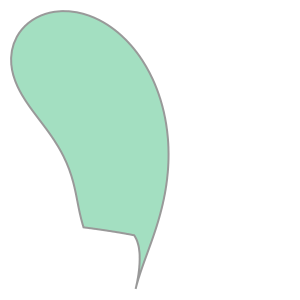

In [182]:
wbars[3].polygon

In [183]:
fig = plt.figure()
ax = fig.add_subplot(111)
count = 0
for wbar in wbars:
    if type(wbar.polygon) == Polygon:
        ax.fill(wbar.polygon.exterior.xy[0], wbar.polygon.exterior.xy[1])
        ax.text(wbar.polygon.centroid.x, wbar.polygon.centroid.y, str(count))
    if type(wbar.polygon) == MultiPolygon:
        for geom in wbar.polygon.geoms:
            ax.fill(geom.exterior.xy[0], geom.exterior.xy[1])
            ax.text(geom.centroid.x, geom.centroid.y, str(count))
    count += 1
plt.axis('equal')

(14512.47867088342, 29341.272741115718, -2909.8187209757953, 2865.273882179424)

In [134]:
fig = plt.figure()
ax = fig.add_subplot(111)
# for wbar in wbars:
mg.plot_migration_rate_map(wbars[6], graph1, graph2, vmin=-30, vmax=30, dt=365*24*60*60, saved_ts=1, ax=ax)
plt.axis('equal');

In [135]:
wbars[6].add_bank_type()

# bar_graph = graph.subgraph(nodes).copy()

In [136]:
wbars[6].bank_type

'right'

In [138]:
bar_graph = poly_graph_1.subgraph(wbars[6].bar_graph.nodes).copy()

In [141]:
bar_graph.nodes[65772]

{'poly': <POLYGON ((27210.217 1506.478, 27251.132 1533.481, 27243.056 1548.081, 27200...>,
 'age': 95,
 'x': 27210.21690180196,
 'y': 1506.4775185302094,
 'length': 16.35194253495665,
 'width': 50.02154515074676,
 'direction': 1,
 'migr_rate': 16.35194253495665,
 'curv': -0.0019434039742462577}

In [142]:
curvs = []
for node in bar_graph.nodes:
    curvs.append(bar_graph.nodes[node]['curv'])
plt.figure()
plt.hist(curvs, 40);

In [145]:
np.max(curvs)

0.006493114721817967

In [152]:
plt.figure()
for node in bar_graph.nodes:
    poly = bar_graph.nodes[node]['poly']
    if type(poly) == Polygon:
        plt.fill(bar_graph.nodes[node]['poly'].exterior.xy[0], bar_graph.nodes[node]['poly'].exterior.xy[1],
                facecolor = m.to_rgba(bar_graph.nodes[node]['curv']*200))
plt.axis('equal')

(26666.580721664737, 28663.786920180304, -540.0108654125544, 2387.130210133967)

In [153]:
wbars[6].bar_graph

In [155]:
plt.figure()
for node in wbars[6].bar_graph.nodes:
    poly = wbars[6].bar_graph.nodes[node]['poly']
    if type(poly) == Polygon:
        plt.fill(wbars[6].bar_graph.nodes[node]['poly'].exterior.xy[0], wbars[6].bar_graph.nodes[node]['poly'].exterior.xy[1],
                facecolor = m.to_rgba(wbars[6].bar_graph.nodes[node]['curv']*200))
plt.axis('equal')

(26666.580721664737, 28663.786920180304, -540.0108654125546, 2387.130210133967)

In [168]:
list(wbars[6].bar_radial_graph.edges)[100]

(65776, 65777)

In [167]:
wbars[6].bar_radial_graph.nodes[65772]

{'x': 27226.408689234508, 'y': 1527.0064126050074}

In [172]:
wbar = wbars[10]
plt.figure()
for s, e in wbar.bar_radial_graph.edges:
    x1 = wbar.bar_radial_graph.nodes[s]['x']
    x2 = wbar.bar_radial_graph.nodes[e]['x']
    y1 = wbar.bar_radial_graph.nodes[s]['y']
    y2 = wbar.bar_radial_graph.nodes[e]['y']
    plt.plot([x1, x2], [y1, y2], 'k')
plt.axis('equal')
    

(17596.391005266996,
 18721.205472252062,
 -488.66819551740724,
 1463.7907905900288)

In [180]:
a = np.array([0,1,2,3,4,5])
a > 1 and a < 4

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [181]:
a > 1

array([False, False,  True,  True,  True,  True])